In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


Load The Excel Sheet.

In [ ]:
# Load dataset
df = pd.read_excel('/content/A_Final Stat Project.xlsx')

# Display first rows
df.head()


,Date,USD To LKR,Data.ASPI
0,2024-09-23,304.8847,11125.47
1,2024-09-24,304.4214,11336.69
2,2024-09-25,303.9075,11699.84
3,2024-09-26,301.7592,11671.87
4,2024-09-27,300.2152,11773.88


Change the Columns Names.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df = df[['Date', 'USD To LKR', 'Data.ASPI']]
df.columns = ['Date', 'USD_LKR', 'ASPI']

df.head()

,Date,USD_LKR,ASPI
0,2024-09-23,304.8847,11125.47
1,2024-09-24,304.4214,11336.69
2,2024-09-25,303.9075,11699.84
3,2024-09-26,301.7592,11671.87
4,2024-09-27,300.2152,11773.88


Check the  -
 Columns,Data types,Missing values,Date correctly datetime64



In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     241 non-null    datetime64[ns]
 1   USD_LKR  241 non-null    float64       
 2   ASPI     241 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 5.8 KB


Check the Descriptive statistics

In [ ]:
df[['USD_LKR', 'ASPI']].describe()


,USD_LKR,ASPI
count,241.000000,241.000000
mean,297.443680,16303.482241
std,3.707825,2615.951987
min,290.259600,11125.470000
25%,294.596300,14654.260000
50%,298.469100,16176.100000
75%,300.670500,17740.460000
max,304.884700,21282.800000


**Plot USD/LKR Exchange Rate Over Time**

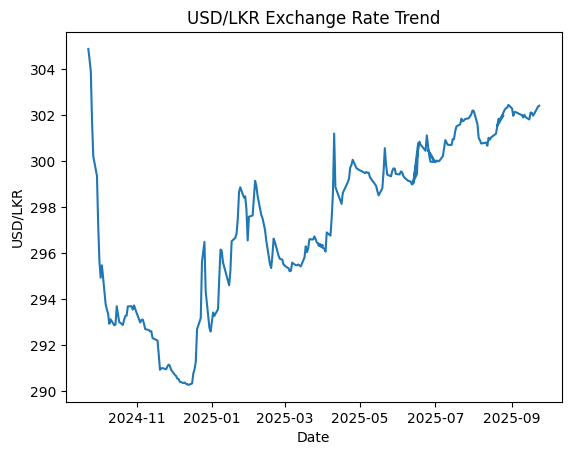

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Date'], df['USD_LKR'])
plt.title("USD/LKR Exchange Rate Trend")
plt.xlabel("Date")
plt.ylabel("USD/LKR")
plt.show()


**Plot ASPI over the Time**

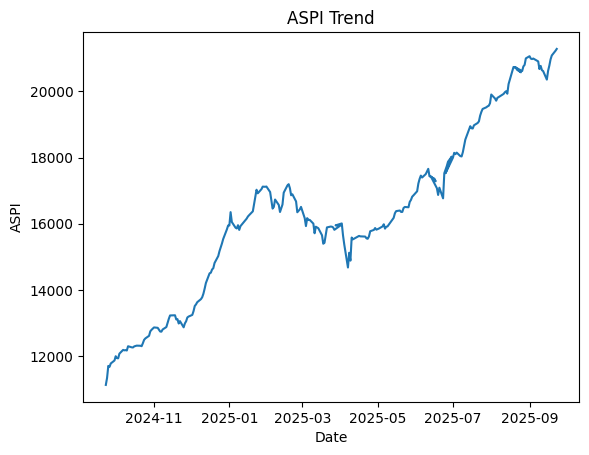

In [ ]:
plt.figure()
plt.plot(df['Date'], df['ASPI'])
plt.title("ASPI Trend")
plt.xlabel("Date")
plt.ylabel("ASPI")
plt.show()

**Check the Correlation & P-value**

In [ ]:
from scipy.stats import pearsonr

# Calculate Pearson correlation and p-value for ASPI and USD_LKR
correlation_coefficient, p_value = pearsonr(df['ASPI'], df['USD_LKR'])

print("Pearson correlation coefficient:", correlation_coefficient)
print("P-value:", p_value)

Pearson correlation coefficient: 0.7324410375768802
P-value: 8.755634216804045e-42


**Chek Stationary (ADF test for original data)**

In [ ]:
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

# 1. The function that checks stationarity
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f'--- ADF Test: {name} ---')
    print(f'p-value: {p_value:.4f}')

    if p_value <= 0.05:
        print(f"Result: {name} is a stationary data set.\n")
        return True
    else:
        print(f"Result: {name} is a Non-Stationary data set. (Need Differencing)\n")
        return False

# 2. Performing the ADF test on the original data
print("Stationarity Test for original data:\n")
is_usd_stationary = check_stationarity(df['USD_LKR'], 'USD_LKR')
is_aspi_stationary = check_stationarity(df['ASPI'], 'ASPI')

Stationarity Test for original data:

--- ADF Test: USD_LKR ---
p-value: 0.5827
Result: USD_LKR is a Non-Stationary data set. (Need Differencing)

--- ADF Test: ASPI ---
p-value: 0.8573
Result: ASPI is a Non-Stationary data set. (Need Differencing)



**Plot ASPI over time and Exchange Rate over time in One Graph**

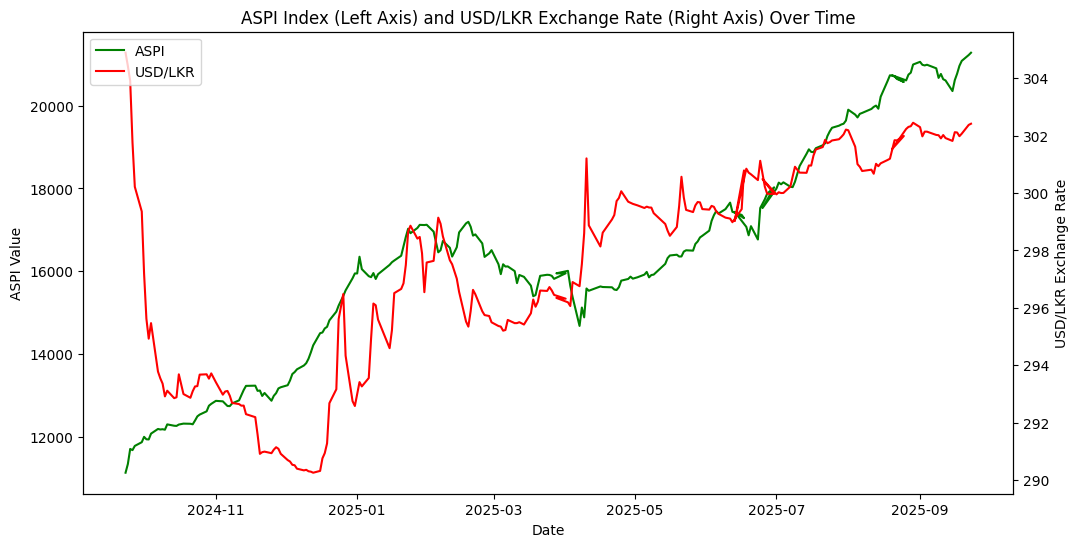

In [ ]:
import matplotlib.pyplot as plt

fig, ax_left = plt.subplots(figsize=(12,6))

# LEFT Y-AXIS → ASPI (change color here)
ax_left.plot(df['Date'], df['ASPI'], color='green', label='ASPI')
ax_left.set_xlabel('Date')
ax_left.set_ylabel('ASPI Value')
ax_left.tick_params(axis='y')

# RIGHT Y-AXIS → USD/LKR
ax_right = ax_left.twinx()
ax_right.plot(df['Date'], df['USD_LKR'], color='red', label='USD/LKR')
ax_right.set_ylabel('USD/LKR Exchange Rate')
ax_right.tick_params(axis='y')


# TITLE
plt.title('ASPI Index (Left Axis) and USD/LKR Exchange Rate (Right Axis) Over Time')

# LEGEND (combine both)
lines_1, labels_1 = ax_left.get_legend_handles_labels()
lines_2, labels_2 = ax_right.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()


**Differencing and Chek stationary fr differenced data**

In [ ]:
# 3. Making the data stationary if they are not stationary (First Difference)
# Often, price data stabilizes after taking their difference.
df_diff = df[['USD_LKR', 'ASPI']].diff().dropna()

print("--- Stationarity test for Differenced Data ---\n")
check_diff_usd = check_stationarity(df_diff['USD_LKR'], 'USD_LKR_diff')
check_diff_aspi = check_stationarity(df_diff['ASPI'], 'ASPI_diff')

--- Stationarity test for Differenced Data ---

--- ADF Test: USD_LKR_diff ---
p-value: 0.0000
Result: USD_LKR_diff is a stationary data set.

--- ADF Test: ASPI_diff ---
p-value: 0.0000
Result: ASPI_diff is a stationary data set.



**Plot Differenced Series**

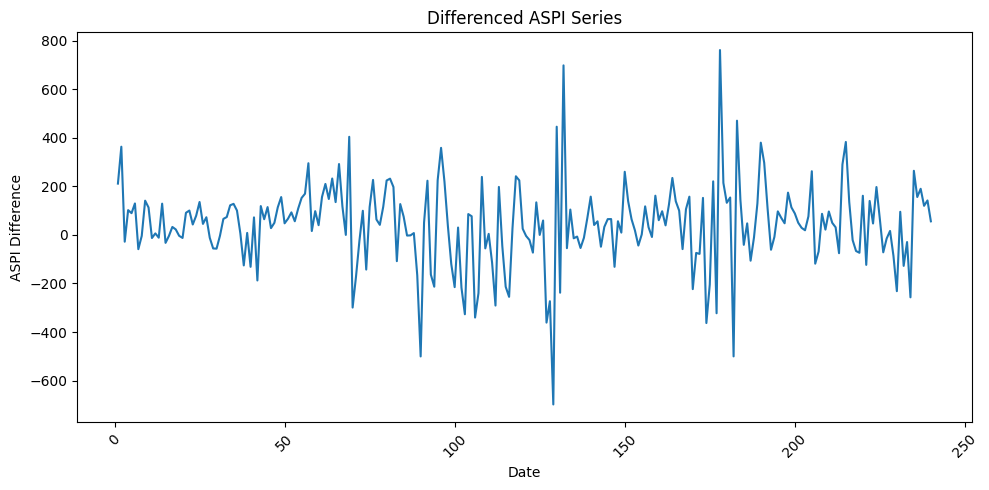

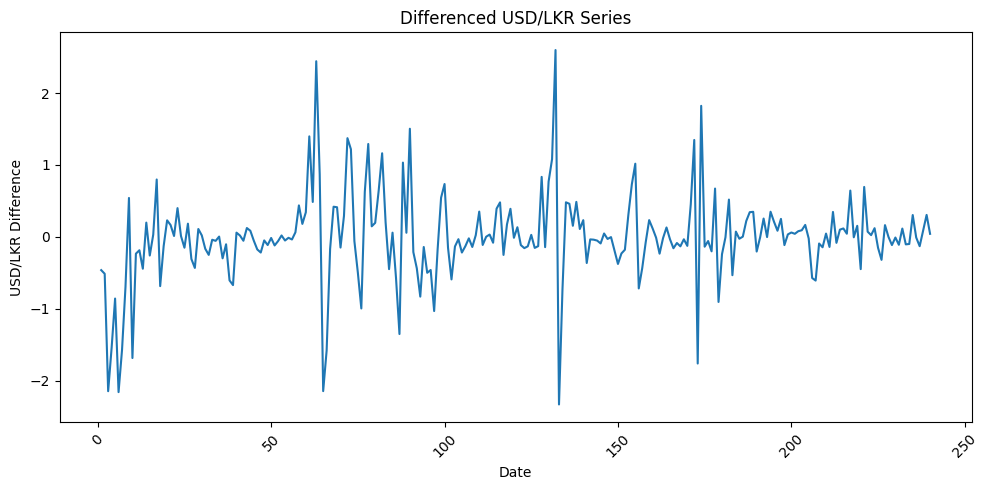

In [ ]:
# Differenced ASPI Plot
plt.figure(figsize=(10,5))
plt.plot(df_diff.index, df_diff['ASPI'])
plt.title("Differenced ASPI Series")
plt.xlabel("Date")
plt.ylabel("ASPI Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Differenced USD/LKR Plot
plt.figure(figsize=(10,5))
plt.plot(df_diff.index, df_diff['USD_LKR'])
plt.title("Differenced USD/LKR Series")
plt.xlabel("Date")
plt.ylabel("USD/LKR Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Granger Causality Test (Using Stationary Data)**

In [ ]:
# 4. Performing the Granger Causality Test (using Differenced/Stationary data)
# Here we are looking at whether a change in one data set affects the change in the other.
print("==========================================================")
print("Granger Causality Test (Using Stationary Data)")
print("==========================================================")

# Test 01: Can USD_LKR predict by ASPI ?
print("\n[Test 01] Direction: ASPI -> USD_LKR")
grangercausalitytests(df_diff[['USD_LKR', 'ASPI']], maxlag=5, verbose=True)

# Test 02: Can ASPI predict by USD_LKR ?
print("\n[Test 02] Direction: USD_LKR -> ASPI")
grangercausalitytests(df_diff[['ASPI', 'USD_LKR']], maxlag=5, verbose=True)

Granger Causality Test (Using Stationary Data)

[Test 01] Direction: ASPI -> USD_LKR

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=8.3783  , p=0.0042  , df_denom=236, df_num=1
ssr based chi2 test:   chi2=8.4848  , p=0.0036  , df=1
likelihood ratio test: chi2=8.3377  , p=0.0039  , df=1
parameter F test:         F=8.3783  , p=0.0042  , df_denom=236, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.2313  , p=0.0157  , df_denom=233, df_num=2
ssr based chi2 test:   chi2=8.6442  , p=0.0133  , df=2
likelihood ratio test: chi2=8.4909  , p=0.0143  , df=2
parameter F test:         F=4.2313  , p=0.0157  , df_denom=233, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.5328  , p=0.0578  , df_denom=230, df_num=3
ssr based chi2 test:   chi2=7.8296  , p=0.0497  , df=3
likelihood ratio test: chi2=7.7030  , p=0.0526  , df=3
parameter F test:         F=2.5328  , p=0.0578  , df_denom=230, df_num=3

Granger 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(0.07733817265658725),
    np.float64(0.7811810677855305),
    np.float64(236.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.07832128502086591),
    np.float64(0.7795853753838555),
    np.int64(1)),
   'lrtest': (np.float64(0.07830845472017245),
    np.float64(0.7796029634839149),
    np.int64(1)),
   'params_ftest': (np.float64(0.07733817265663745),
    np.float64(0.7811810677854943),
    np.float64(236.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.0678593747551788),
    np.float64(0.34541973284040545),
    np.float64(233.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(2.1815496239633694),
    np.float64(0.33595609003393956),
    np.int64(2)),
   'lrtest': (np.float64(2.1716120713404052),
    np.float64(0.33762953473906804),
    np.int64(2)),
   'params_ftest': (np.float64(1.0678593747551515),
    np.float64(0.345419732840418),
    np.float64(233.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],


**Johansen Cointegration Test**

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# 1. Preparing data for cointegration testing (original data can be used)
# The cointegration test is used to see if there is a relationship between non-stationary data.
coint_df = df[['ASPI', 'USD_LKR']].dropna()

# 2. Performing the Johansen Cointegration Test
# det_order=0 (constant term), k_ar_diff=1 (lag order)
result = coint_johansen(coint_df, det_order=0, k_ar_diff=1)

# 3. Displaying results in a table
print("--- Johansen Cointegration Test Results ---")
print(f"{'Rank':<10} {'Trace Statistic':<20} {'Critical Value (95%)':<20}")

for i in range(len(result.lr1)):
    rank = i
    trace_stat = result.lr1[i]
    crit_val = result.cvt[i, 1]  # 1 refers to 95% confidence level
    print(f"{rank:<10} {trace_stat:<20.4f} {crit_val:<20.4f}")

# 4. Explanation of the result
print("\n--- Conclusion ---")
if result.lr1[0] > result.cvt[0, 1]:
    print("Conclusion: There is cointegration between the data series. (There is a long-term relationship)")
else:
    print("Conclusion: There is no cointegration between the data series. (No long-run relationship)")

--- Johansen Cointegration Test Results ---
Rank       Trace Statistic      Critical Value (95%)
0          33.4912              15.4943             
1          0.0007               3.8415              

--- Conclusion ---
Conclusion: There is cointegration between the data series. (There is a long-term relationship)


**Cointegration Residual Plot**

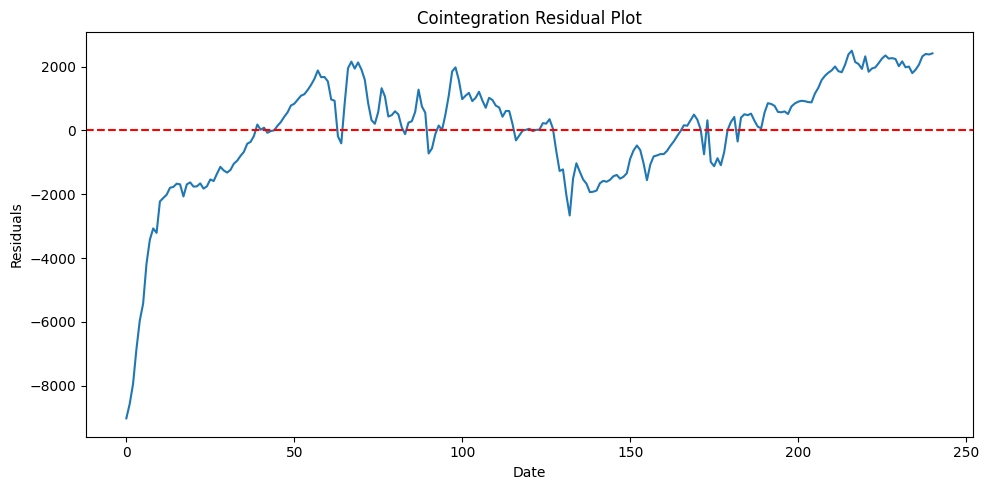

ADF Test on Residuals
ADF Statistic: -5.056044850261425
p-value: 1.717111341374757e-05


In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# -------------------------------
# Step 1: Run Long Run Regression
# -------------------------------

X = sm.add_constant(df['USD_LKR'])   # Independent variable
model = sm.OLS(df['ASPI'], X).fit()

# -------------------------------
# Step 2: Extract Residuals
# -------------------------------

residuals = model.resid

# -------------------------------
# Step 3: Plot Residuals
# -------------------------------

plt.figure(figsize=(10,5))
plt.plot(df.index, residuals)
plt.title("Cointegration Residual Plot")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# -------------------------------
# Step 4: ADF Test on Residuals
# -------------------------------

result = adfuller(residuals.dropna())

print("ADF Test on Residuals")
print("ADF Statistic:", result[0])
print("p-value:", result[1])


**Chek VECM**

In [ ]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Level data use කරන්න
vecm_data = df[['ASPI', 'USD_LKR']].dropna()

# Build VECM Model
vecm_model = VECM(vecm_data, k_ar_diff=1, coint_rank=1)

vecm_result = vecm_model.fit()

# Model Summary
print(vecm_result.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ASPI
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.ASPI        0.0339      0.064      0.527      0.598      -0.092       0.160
L1.USD_LKR     6.6937     18.089      0.370      0.711     -28.760      42.147
Det. terms outside the coint. relation & lagged endog. parameters for equation USD_LKR
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.ASPI       -0.0006      0.000     -2.820      0.005      -0.001      -0.000
L1.USD_LKR     0.1819      0.062      2.912      0.004       0.059       0.304
                Loading coefficients (alpha) for equation ASPI                
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

**Simple Linear Regression model**

In [ ]:
import statsmodels.api as sm

# Select variables
X = df['USD_LKR']
y = df['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit model
model_slr = sm.OLS(y, X).fit()

# Summary
print(model_slr.summary())



                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     276.6
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           8.76e-42
Time:                        04:46:41   Log-Likelihood:                -2145.3
No. Observations:                 241   AIC:                             4295.
Df Residuals:                     239   BIC:                             4302.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.374e+05   9242.487    -14.866      0.0

**Check NMSE, RMSE, MSE, MAE & R square for Simple Linear Regression Model**

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

# Prepare data
df_slr = df[['ASPI', 'USD_LKR']].dropna()

y = df_slr['ASPI']
X = sm.add_constant(df_slr['USD_LKR'])

# Fit model
model_slr = sm.OLS(y, X).fit()

# Predictions
y_pred = model_slr.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)


MSE : 3158869.628807576
RMSE : 1777.3209132870675
MAE : 1267.868735180942
NMSE : 0.46353012647330327
R-squared : 0.5364698735266968


**Multiple Linear Regression model with One lag of USD**

In [ ]:
import statsmodels.api as sm

# Create lag 1 of USD/LKR
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)

# Drop missing values caused by lag
df_mlr = df[['ASPI', 'USD_LKR', 'USD_LKR_lag1']].dropna()

# Define variables
X = df_mlr[['USD_LKR', 'USD_LKR_lag1']]
y = df_mlr['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit model
model_mlr_lag1 = sm.OLS(y, X).fit()

# Summary
print(model_mlr_lag1.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     171.4
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           8.97e-47
Time:                        04:46:48   Log-Likelihood:                -2119.8
No. Observations:                 240   AIC:                             4246.
Df Residuals:                     237   BIC:                             4256.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.423e+05   8729.817    -16.303   

**Check NMSE, RMSE, MSE, MAE & R square for Multiple Linear Regression Model With USD lag 1**

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create lag 1
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)

# Prepare dataset
df_mlr1 = df[['ASPI', 'USD_LKR', 'USD_LKR_lag1']].dropna()

y = df_mlr1['ASPI']
X = df_mlr1[['USD_LKR', 'USD_LKR_lag1']]
X = sm.add_constant(X)

# Fit model
model_mlr1 = sm.OLS(y, X).fit()

# Predictions
y_pred = model_mlr1.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)


MSE : 2751051.6793420645
RMSE : 1658.629458119584
MAE : 1238.8986876761453
NMSE : 0.40871224190675015
R-squared : 0.5912877580932496


**Multiple Linear Regression model with Two lags of USD**

In [ ]:
import statsmodels.api as sm

# Create lags
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)

# Drop NA values
df_mlr = df[['ASPI', 'USD_LKR', 'USD_LKR_lag1', 'USD_LKR_lag2']].dropna()

# Define X and y
X = df_mlr[['USD_LKR', 'USD_LKR_lag1', 'USD_LKR_lag2']]
y = df_mlr['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit model
model_mlr_lag12 = sm.OLS(y, X).fit()

# Print summary
print(model_mlr_lag12.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     136.7
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           2.84e-51
Time:                        04:46:55   Log-Likelihood:                -2095.9
No. Observations:                 239   AIC:                             4200.
Df Residuals:                     235   BIC:                             4214.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -1.47e+05   8301.763    -17.705   

**Check NMSE, RMSE, MSE, MAE & R square for Multiple Linear Regression Model With USD lag 1 & 2**

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create lags
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)

# Prepare dataset
df_mlr2 = df[['ASPI', 'USD_LKR', 'USD_LKR_lag1', 'USD_LKR_lag2']].dropna()

y = df_mlr2['ASPI']
X = df_mlr2[['USD_LKR', 'USD_LKR_lag1', 'USD_LKR_lag2']]
X = sm.add_constant(X)

# Fit model
model_mlr2 = sm.OLS(y, X).fit()

# Predictions
y_pred = model_mlr2.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)


MSE : 2423832.2078052456
RMSE : 1556.8661496112136
MAE : 1200.710370038098
NMSE : 0.3642321940046519
R-squared : 0.6357678059953481


**Multiple Linear Regression model with Tree lags of USD**

In [ ]:
import statsmodels.api as sm

# Create lags
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)
df['USD_LKR_lag3'] = df['USD_LKR'].shift(3)

# Drop missing values
df_mlr = df[['ASPI', 'USD_LKR',
             'USD_LKR_lag1', 'USD_LKR_lag2', 'USD_LKR_lag3']].dropna()

# Define dependent and independent variables
X = df_mlr[['USD_LKR', 'USD_LKR_lag1', 'USD_LKR_lag2', 'USD_LKR_lag3']]
y = df_mlr['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model_mlr_lag123 = sm.OLS(y, X).fit()

# Print results
print(model_mlr_lag123.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     121.5
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           7.66e-56
Time:                        04:47:02   Log-Likelihood:                -2072.1
No. Observations:                 238   AIC:                             4154.
Df Residuals:                     233   BIC:                             4171.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.512e+05   7891.572    -19.154   

**Check NMSE, RMSE, MSE, MAE & R square for Multiple Linear Regression Model With USD lag 1,2 & 3**

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create USD lags
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)
df['USD_LKR_lag3'] = df['USD_LKR'].shift(3)

# Prepare dataset
df_mlr3 = df[['ASPI', 'USD_LKR',
              'USD_LKR_lag1',
              'USD_LKR_lag2',
              'USD_LKR_lag3']].dropna()

y = df_mlr3['ASPI']
X = df_mlr3[['USD_LKR',
             'USD_LKR_lag1',
             'USD_LKR_lag2',
             'USD_LKR_lag3']]

X = sm.add_constant(X)

# Fit multiple linear regression
model_mlr3 = sm.OLS(y, X).fit()

# Predictions
y_pred = model_mlr3.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

# Print results
print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)

# Optional: model summary
model_mlr3.summary()


MSE : 2135809.473284767
RMSE : 1461.44088942549
MAE : 1163.6183732380696
NMSE : 0.3240240037400211
R-squared : 0.675975996259979


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   ASPI   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     121.5
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           7.66e-56
Time:                        04:47:06   Log-Likelihood:                -2072.1
No. Observations:                 238   AIC:                             4154.
Df Residuals:                     233   BIC:                             4171.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.512e+05   7891.572    -19.154      0.000   -1.67e+05   -1.36e+05
USD_LKR        861.2161    159.394      5.403      0.000     547.178    1175.255
USD_LKR_lag1  -112.5408    245.115     -0.459      0.647    -595.466     370.384
USD_LKR_lag2    89.9212    245.124      0.367      0.714    -393.021     572.863
USD_LKR_lag3  -275.2154    158.534     -1.736      0.084    -587.558      37.127
==============================================================================
Omnibus:                       24.793   Durbin-Watson:                   0.151
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.678
Skew:                          -0.702   Prob(JB):                     8.02e-08
Kurtosis:                       4.150   Cond. No.                     4.90e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.9e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Multiple Linear Regression model with four lags of USD**

In [ ]:
import statsmodels.api as sm

# Create lags up to 4
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)
df['USD_LKR_lag3'] = df['USD_LKR'].shift(3)
df['USD_LKR_lag4'] = df['USD_LKR'].shift(4)

# Keep only required columns and drop NaNs
df_mlr = df[['ASPI', 'USD_LKR',
             'USD_LKR_lag1', 'USD_LKR_lag2',
             'USD_LKR_lag3', 'USD_LKR_lag4']].dropna()

# Dependent and independent variables
X = df_mlr[['USD_LKR', 'USD_LKR_lag1',
             'USD_LKR_lag2', 'USD_LKR_lag3',
             'USD_LKR_lag4']]
y = df_mlr['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model_mlr_lag1234 = sm.OLS(y, X).fit()

# Summary
print(model_mlr_lag1234.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     109.4
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           6.96e-59
Time:                        04:47:10   Log-Likelihood:                -2051.8
No. Observations:                 237   AIC:                             4116.
Df Residuals:                     231   BIC:                             4136.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.536e+05   7593.955    -20.232   

**Check NMSE, RMSE, MSE, MAE & R square for Multiple Linear Regression Model With USD lag 1,2,3 & 4**

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create USD lags
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)
df['USD_LKR_lag3'] = df['USD_LKR'].shift(3)
df['USD_LKR_lag4'] = df['USD_LKR'].shift(4)

# Prepare dataset
df_mlr4 = df[['ASPI', 'USD_LKR',
              'USD_LKR_lag1',
              'USD_LKR_lag2',
              'USD_LKR_lag3',
              'USD_LKR_lag4']].dropna()

y = df_mlr4['ASPI']
X = df_mlr4[['USD_LKR',
             'USD_LKR_lag1',
             'USD_LKR_lag2',
             'USD_LKR_lag3',
             'USD_LKR_lag4']]

X = sm.add_constant(X)

# Fit model
model_mlr4 = sm.OLS(y, X).fit()

# Predictions
y_pred = model_mlr4.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

# Print results
print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)

# Optional summary
model_mlr4.summary()


MSE : 1937795.5658831294
RMSE : 1392.0472570581537
MAE : 1126.2930553252188
NMSE : 0.2969353841579513
R-squared : 0.7030646158420488


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   ASPI   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     109.4
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           6.96e-59
Time:                        04:47:14   Log-Likelihood:                -2051.8
No. Observations:                 237   AIC:                             4116.
Df Residuals:                     231   BIC:                             4136.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.536e+05   7593.955    -20.232      0.000   -1.69e+05   -1.39e+05
USD_LKR        708.4441    155.594      4.553      0.000     401.880    1015.009
USD_LKR_lag1    38.1787    236.347      0.162      0.872    -427.493     503.850
USD_LKR_lag2    21.2340    235.479      0.090      0.928    -442.728     485.195
USD_LKR_lag3    73.7214    234.040      0.315      0.753    -387.404     534.846
USD_LKR_lag4  -269.7206    151.344     -1.782      0.076    -567.912      28.471
==============================================================================
Omnibus:                       10.155   Durbin-Watson:                   0.120
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               10.214
Skew:                          -0.484   Prob(JB):                      0.00606
Kurtosis:                       3.311   Cond. No.                     5.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Multiple Linear Regression model with five lags of USD**

In [ ]:
import statsmodels.api as sm

# Create lags up to 5
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)
df['USD_LKR_lag3'] = df['USD_LKR'].shift(3)
df['USD_LKR_lag4'] = df['USD_LKR'].shift(4)
df['USD_LKR_lag5'] = df['USD_LKR'].shift(5)

# Select relevant columns and drop missing values
df_mlr = df[['ASPI', 'USD_LKR',
             'USD_LKR_lag1', 'USD_LKR_lag2',
             'USD_LKR_lag3', 'USD_LKR_lag4',
             'USD_LKR_lag5']].dropna()

# Define X and y
X = df_mlr[['USD_LKR',
             'USD_LKR_lag1', 'USD_LKR_lag2',
             'USD_LKR_lag3', 'USD_LKR_lag4',
             'USD_LKR_lag5']]
y = df_mlr['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit the model
model_mlr_lag5 = sm.OLS(y, X).fit()

# Print results
print(model_mlr_lag5.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     99.81
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           4.42e-61
Time:                        04:47:20   Log-Likelihood:                -2033.7
No. Observations:                 236   AIC:                             4081.
Df Residuals:                     229   BIC:                             4106.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.553e+05   7368.965    -21.081   

**Check NMSE, RMSE, MSE, MAE & R square for Multiple Linear Regression Model With USD lag 1,2,3,4 & 5**

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create USD lags up to 5
for i in range(1, 6):
    df[f'USD_LKR_lag{i}'] = df['USD_LKR'].shift(i)

# Prepare dataset
df_mlr5 = df[['ASPI', 'USD_LKR',
              'USD_LKR_lag1',
              'USD_LKR_lag2',
              'USD_LKR_lag3',
              'USD_LKR_lag4',
              'USD_LKR_lag5']].dropna()

y = df_mlr5['ASPI']
X = df_mlr5[['USD_LKR',
             'USD_LKR_lag1',
             'USD_LKR_lag2',
             'USD_LKR_lag3',
             'USD_LKR_lag4',
             'USD_LKR_lag5']]

X = sm.add_constant(X)

# Fit model
model_mlr5 = sm.OLS(y, X).fit()

# Predictions
y_pred = model_mlr5.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

# Print metrics
print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)

# Optional: regression summary
model_mlr5.summary()


MSE : 1787848.2201028073
RMSE : 1337.1044163051768
MAE : 1095.3668731525602
NMSE : 0.2766218184477499
R-squared : 0.72337818155225


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   ASPI   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     99.81
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           4.42e-61
Time:                        04:47:24   Log-Likelihood:                -2033.7
No. Observations:                 236   AIC:                             4081.
Df Residuals:                     229   BIC:                             4106.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.553e+05   7368.965    -21.081      0.000    -1.7e+05   -1.41e+05
USD_LKR        599.1744    152.090      3.940      0.000     299.499     898.850
USD_LKR_lag1    30.4767    228.588      0.133      0.894    -419.927     480.881
USD_LKR_lag2   135.8713    228.603      0.594      0.553    -314.562     586.305
USD_LKR_lag3    12.1212    226.756      0.053      0.957    -434.674     458.916
USD_LKR_lag4    41.8655    226.276      0.185      0.853    -403.984     487.715
USD_LKR_lag5  -241.8435    146.817     -1.647      0.101    -531.128      47.441
==============================================================================
Omnibus:                        4.578   Durbin-Watson:                   0.106
Prob(Omnibus):                  0.101   Jarque-Bera (JB):                4.678
Skew:                          -0.333   Prob(JB):                       0.0964
Kurtosis:                       2.818   Cond. No.                     6.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Multiple Linear Regression model with one lag of ASPI**

In [ ]:
import statsmodels.api as sm

# Create USD lags (1–5)
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)
df['USD_LKR_lag3'] = df['USD_LKR'].shift(3)
df['USD_LKR_lag4'] = df['USD_LKR'].shift(4)
df['USD_LKR_lag5'] = df['USD_LKR'].shift(5)

# Create ASPI lag 1
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Keep only required columns and drop NaNs
df_dyn = df[['ASPI', 'USD_LKR',
             'USD_LKR_lag1', 'USD_LKR_lag2',
             'USD_LKR_lag3', 'USD_LKR_lag4',
             'USD_LKR_lag5',
             'ASPI_lag1']].dropna()

# Define X and y
X = df_dyn[['USD_LKR',
            'USD_LKR_lag1', 'USD_LKR_lag2',
            'USD_LKR_lag3', 'USD_LKR_lag4',
            'USD_LKR_lag5',
            'ASPI_lag1']]
y = df_dyn['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model_ardl_style = sm.OLS(y, X).fit()

# Print summary
print(model_ardl_style.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     7352.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.28e-264
Time:                        04:47:28   Log-Likelihood:                -1545.3
No. Observations:                 236   AIC:                             3107.
Df Residuals:                     228   BIC:                             3134.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1916.5243   1594.541     -1.202   

**Check NMSE, RMSE, MSE, MAE & R square for Multiple Linear Regression Model With all USD lags & ASPI lag 1**

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create USD lags (1–5)
for i in range(1, 6):
    df[f'USD_LKR_lag{i}'] = df['USD_LKR'].shift(i)

# Create ASPI lag 1
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Prepare dataset
df_mlr_ardl = df[['ASPI', 'USD_LKR',
                  'USD_LKR_lag1',
                  'USD_LKR_lag2',
                  'USD_LKR_lag3',
                  'USD_LKR_lag4',
                  'USD_LKR_lag5',
                  'ASPI_lag1']].dropna()

y = df_mlr_ardl['ASPI']

X = df_mlr_ardl[['USD_LKR',
                 'USD_LKR_lag1',
                 'USD_LKR_lag2',
                 'USD_LKR_lag3',
                 'USD_LKR_lag4',
                 'USD_LKR_lag5',
                 'ASPI_lag1']]

X = sm.add_constant(X)

# Fit model
model_mlr_ardl = sm.OLS(y, X).fit()

# Predictions
y_pred = model_mlr_ardl.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

# Print results
print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)

# Regression summary (optional but recommended)
model_mlr_ardl.summary()


MSE : 28507.304710548946
RMSE : 168.84106346072613
MAE : 118.75401854762424
NMSE : 0.004410744927565887
R-squared : 0.9955892550724341


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   ASPI   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     7352.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.28e-264
Time:                        04:47:33   Log-Likelihood:                -1545.3
No. Observations:                 236   AIC:                             3107.
Df Residuals:                     228   BIC:                             3134.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1916.5243   1594.541     -1.202      0.231   -5058.445    1225.397
USD_LKR         -4.9876     19.910     -0.251      0.802     -44.218      34.243
USD_LKR_lag1    18.0669     28.928      0.625      0.533     -38.934      75.067
USD_LKR_lag2    19.5960     28.946      0.677      0.499     -37.441      76.633
USD_LKR_lag3   -30.1303     28.698     -1.050      0.295     -86.678      26.417
USD_LKR_lag4    46.4022     28.635      1.620      0.107     -10.022     102.826
USD_LKR_lag5   -41.6866     18.656     -2.234      0.026     -78.447      -4.926
ASPI_lag1        0.9877      0.008    118.622      0.000       0.971       1.004
==============================================================================
Omnibus:                       25.556   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               97.497
Skew:                          -0.278   Prob(JB):                     6.74e-22
Kurtosis:                       6.099   Cond. No.                     2.36e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.36e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Multiple Linear Regression model with Two lags of ASPI**

In [ ]:
import statsmodels.api as sm

# USD lags 1–5
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['USD_LKR_lag2'] = df['USD_LKR'].shift(2)
df['USD_LKR_lag3'] = df['USD_LKR'].shift(3)
df['USD_LKR_lag4'] = df['USD_LKR'].shift(4)
df['USD_LKR_lag5'] = df['USD_LKR'].shift(5)

# ASPI lags 1 & 2
df['ASPI_lag1'] = df['ASPI'].shift(1)
df['ASPI_lag2'] = df['ASPI'].shift(2)

# Select variables and drop missing values
df_model = df[['ASPI', 'USD_LKR',
               'USD_LKR_lag1', 'USD_LKR_lag2',
               'USD_LKR_lag3', 'USD_LKR_lag4',
               'USD_LKR_lag5',
               'ASPI_lag1', 'ASPI_lag2']].dropna()

# Define dependent and independent variables
y = df_model['ASPI']
X = df_model[['USD_LKR',
              'USD_LKR_lag1', 'USD_LKR_lag2',
              'USD_LKR_lag3', 'USD_LKR_lag4',
              'USD_LKR_lag5',
              'ASPI_lag1', 'ASPI_lag2']]

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     6411.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.03e-262
Time:                        04:47:38   Log-Likelihood:                -1545.2
No. Observations:                 236   AIC:                             3108.
Df Residuals:                     227   BIC:                             3140.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1964.8276   1600.926     -1.227   

**Check NMSE, RMSE, MSE, MAE & R square for Multiple Linear Regression Model With all USD lags & ASPI lag 1 & 2**

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create USD lags (1–5)
for i in range(1, 6):
    df[f'USD_LKR_lag{i}'] = df['USD_LKR'].shift(i)

# Create ASPI lag 1
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Prepare dataset
df_mlr_ardl = df[['ASPI', 'USD_LKR',
                  'USD_LKR_lag1',
                  'USD_LKR_lag2',
                  'USD_LKR_lag3',
                  'USD_LKR_lag4',
                  'USD_LKR_lag5',
                  'ASPI_lag1',
                  'ASPI_lag2']].dropna()

y = df_mlr_ardl['ASPI']

X = df_mlr_ardl[['USD_LKR',
                 'USD_LKR_lag1',
                 'USD_LKR_lag2',
                 'USD_LKR_lag3',
                 'USD_LKR_lag4',
                 'USD_LKR_lag5',
                 'ASPI_lag1',
                 'ASPI_lag2']]

X = sm.add_constant(X)

# Fit model
model_mlr_ardl = sm.OLS(y, X).fit()

# Predictions
y_pred = model_mlr_ardl.predict(X)

# Evaluation metrics
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

# Print results
print("MSE :", MSE)
print("RMSE :", RMSE)
print("MAE :", MAE)
print("NMSE :", NMSE)
print("R-squared :", R2)

# Regression summary (optional but recommended)
model_mlr_ardl.summary()


MSE : 28481.815843933644
RMSE : 168.7655647456958
MAE : 118.3105229006076
NMSE : 0.004406801205412062
R-squared : 0.995593198794588


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   ASPI   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     6411.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.03e-262
Time:                        04:47:43   Log-Likelihood:                -1545.2
No. Observations:                 236   AIC:                             3108.
Df Residuals:                     227   BIC:                             3140.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1964.8276   1600.926     -1.227      0.221   -5119.404    1189.749
USD_LKR         -3.3133     20.287     -0.163      0.870     -43.289      36.663
USD_LKR_lag1    16.6396     29.151      0.571      0.569     -40.802      74.081
USD_LKR_lag2    19.4791     28.998      0.672      0.502     -37.661      76.619
USD_LKR_lag3   -30.7007     28.776     -1.067      0.287     -87.404      26.002
USD_LKR_lag4    46.9233     28.709      1.634      0.104      -9.647     103.493
USD_LKR_lag5   -41.5920     18.690     -2.225      0.027     -78.420      -4.764
ASPI_lag1        1.0174      0.066     15.326      0.000       0.887       1.148
ASPI_lag2       -0.0300      0.067     -0.451      0.653      -0.161       0.101
==============================================================================
Omnibus:                       24.999   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.927
Skew:                          -0.239   Prob(JB):                     3.30e-22
Kurtosis:                       6.136   Cond. No.                     3.34e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.34e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Dynamic Multiple Linear Regression**(Chat eken awa)

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Create lag variables
df['USD_lag1'] = df['USD_LKR'].shift(1)
df['USD_lag2'] = df['USD_LKR'].shift(2)
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Drop missing values due to lags
df_model = df.dropna()
# Dependent variable
y = df_model['ASPI']

# Independent variables
X = df_model[['USD_LKR', 'USD_lag1', 'USD_lag2', 'ASPI_lag1']]

# Add constant (β0)
X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()

# Summary output
print(results.summary())
results_robust = model.fit(cov_type='HC3')
print(results_robust.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.265e+04
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          3.25e-269
Time:                        04:47:48   Log-Likelihood:                -1548.8
No. Observations:                 236   AIC:                             3108.
Df Residuals:                     231   BIC:                             3125.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1766.0753   1605.642     -1.100      0.2

**Simple Linear Regression model with ASPI lag 1**

In [ ]:
import statsmodels.api as sm

# Create ASPI lag 1
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Drop missing values caused by lag
df_model = df.dropna()

# Select variables
X = df_model[['USD_LKR', 'ASPI_lag1']]
y = df_model['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit model
model_mlr = sm.OLS(y, X).fit()

# Summary
print(model_mlr.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 2.548e+04
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.52e-273
Time:                        04:47:53   Log-Likelihood:                -1549.0
No. Observations:                 236   AIC:                             3104.
Df Residuals:                     233   BIC:                             3114.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1770.0208   1598.301     -1.107      0.2

**Multiple linear Regression model with USD lag 1 and ASPI lag 1**

In [ ]:
# Create ASPI lag 1
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Drop missing values caused by lag
df_model = df.dropna()
X = df_model[['USD_LKR', 'USD_LKR_lag1', 'ASPI_lag1']]
y = df_model['ASPI']

# ===============================
# 8. Add constant
# ===============================
X = sm.add_constant(X)

# ===============================
# 9. Fit OLS model
# ===============================
model = sm.OLS(y, X).fit()

# ===============================
# 10. Model summary
# ===============================
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.692e+04
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          2.58e-271
Time:                        04:47:58   Log-Likelihood:                -1549.0
No. Observations:                 236   AIC:                             3106.
Df Residuals:                     232   BIC:                             3120.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1789.1577   1602.263     -1.117   

**Mltiple Linear Regression model with USD lag 1 and ASPI Lag 1(Without actual USD value)**

In [ ]:
import statsmodels.api as sm
import pandas as pd

# create lagged variables
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['ASPI_lag1'] = df['ASPI'].shift(1)

# drop missing values caused by lagging
df_model = df[['ASPI', 'USD_LKR_lag1', 'ASPI_lag1']].dropna()
# dependent variable
y = df_model['ASPI']

# independent variables
X = df_model[['USD_LKR_lag1', 'ASPI_lag1']]

# add constant (β0)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 2.716e+04
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.26e-280
Time:                        04:48:02   Log-Likelihood:                -1574.6
No. Observations:                 240   AIC:                             3155.
Df Residuals:                     237   BIC:                             3166.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -2118.7442   1236.392     -1.714   

**Check MSE, RMSE, MAE, NMSE and R square of above model**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1. Create lag variables
# -----------------------------
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Drop missing values due to lagging
df_model = df[['ASPI', 'USD_LKR_lag1', 'ASPI_lag1']].dropna()

# -----------------------------
# 2. Define X and y
# -----------------------------
X = df_model[['USD_LKR_lag1', 'ASPI_lag1']]
y = df_model['ASPI']

# Add constant
X = sm.add_constant(X)

# -----------------------------
# 3. Fit OLS model
# -----------------------------
model = sm.OLS(y, X).fit()

# Model summary
print(model.summary())

# -----------------------------
# 4. Predictions
# -----------------------------
y_pred = model.predict(X)

# -----------------------------
# 5. Error metrics
# -----------------------------
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y, y_pred)
NMSE = MSE / np.var(y)
R2 = r2_score(y, y_pred)

# -----------------------------
# 6. Print results
# -----------------------------
print("\nModel Performance Metrics")
print(f"MSE  : {MSE}")
print(f"RMSE : {RMSE}")
print(f"MAE  : {MAE}")
print(f"NMSE : {NMSE}")
print(f"R²   : {R2}")


                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 2.716e+04
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.26e-280
Time:                        04:48:06   Log-Likelihood:                -1574.6
No. Observations:                 240   AIC:                             3155.
Df Residuals:                     237   BIC:                             3166.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -2118.7442   1236.392     -1.714   

**Check the Overfitting to saparately Test and Train DataModel with ASPI lag 1 and USD lag 1-without actual USD value)**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1. Create lag variables
# -----------------------------
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Keep relevant columns & drop NA
df_model = df[['ASPI', 'USD_LKR_lag1', 'ASPI_lag1']].dropna().reset_index(drop=True)

# -----------------------------
# 2. Train-Test split (80%-20%)
# -----------------------------
train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test  = df_model.iloc[train_size:]

# -----------------------------
# 3. Define X and y (TRAIN)
# -----------------------------
X_train = train[['USD_LKR_lag1', 'ASPI_lag1']]
y_train = train['ASPI']

X_train = sm.add_constant(X_train)

# -----------------------------
# 4. Fit model on TRAIN
# -----------------------------
model = sm.OLS(y_train, X_train).fit()

print("TRAIN MODEL SUMMARY")
print(model.summary())

# -----------------------------
# 5. Predictions
# -----------------------------
# Train predictions
y_train_pred = model.predict(X_train)

# Test predictions
X_test = test[['USD_LKR_lag1', 'ASPI_lag1']]
X_test = sm.add_constant(X_test)

y_test = test['ASPI']
y_test_pred = model.predict(X_test)

# -----------------------------
# 6. Performance metrics function
# -----------------------------
def metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    nmse = mse / np.var(y_true)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{label} PERFORMANCE")
    print(f"MSE  : {mse}")
    print(f"RMSE : {rmse}")
    print(f"MAE  : {mae}")
    print(f"NMSE : {nmse}")
    print(f"R²   : {r2}")

# -----------------------------
# 7. Evaluate Train vs Test
# -----------------------------
metrics(y_train, y_train_pred, "TRAIN")
metrics(y_test, y_test_pred, "TEST")


TRAIN MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                   ASPI   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 1.013e+04
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          5.96e-193
Time:                        04:48:10   Log-Likelihood:                -1269.5
No. Observations:                 192   AIC:                             2545.
Df Residuals:                     189   BIC:                             2555.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1931.1818   13

✔ Model is stable
✔ Model is not overfitted
✔ Model is defensible for a research project
- MSE eka Overfitting indicator එකක් නොවෙයි

**Actual value and Predict value plot(Model with ASPI lag 1 and USD lag 1-without actual USD value)**

/tmp/ipython-input-404654610.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['ASPI_Predicted'] = model.predict(X)


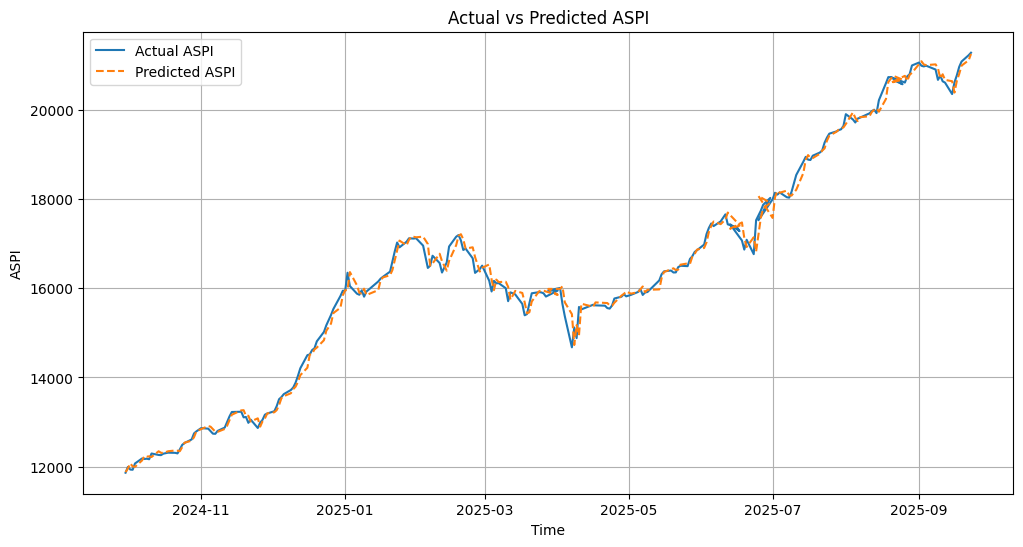

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Create lag variables
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Drop missing values due to lagging
df_model = df.dropna()
# Define X and y
X = df_model[['USD_LKR_lag1', 'ASPI_lag1']]
y = df_model['ASPI']

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Predicted values
df_model['ASPI_Predicted'] = model.predict(X)
plt.figure(figsize=(12,6))

plt.plot(df_model['Date'], df_model['ASPI'], label='Actual ASPI')
plt.plot(df_model['Date'], df_model['ASPI_Predicted'], linestyle='--', label='Predicted ASPI')

plt.xlabel('Time')
plt.ylabel('ASPI')
plt.title('Actual vs Predicted ASPI')
plt.legend()
plt.grid(True)

plt.show()


**ML model related to Above Mode(lModel with ASPI lag 1 and USD lag 1-without actual USD value)**

In [ ]:
import pandas as pd

# Create lag variables
df['USD_LKR_lag1'] = df['USD_LKR'].shift(1)
df['ASPI_lag1'] = df['ASPI'].shift(1)

# Drop missing values due to lagging
df_ml = df.dropna().copy()
X = df_ml[['USD_LKR_lag1', 'ASPI_lag1']]
y = df_ml['ASPI']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
from sklearn.linear_model import LinearRegression

ml_lr = LinearRegression()
ml_lr.fit(X_train, y_train)

y_train_pred = ml_lr.predict(X_train)
y_test_pred = ml_lr.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    nmse = mse / np.var(y_true)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, nmse, r2

mse_tr, rmse_tr, mae_tr, nmse_tr, r2_tr = regression_metrics(y_train, y_train_pred)

print("TRAIN PERFORMANCE")
print(f"MSE  : {mse_tr}")
print(f"RMSE : {rmse_tr}")
print(f"MAE  : {mae_tr}")
print(f"NMSE : {nmse_tr}")
print(f"R²   : {r2_tr}")

mse_te, rmse_te, mae_te, nmse_te, r2_te = regression_metrics(y_test, y_test_pred)

print("\nTEST PERFORMANCE")
print(f"MSE  : {mse_te}")
print(f"RMSE : {rmse_te}")
print(f"MAE  : {mae_te}")
print(f"NMSE : {nmse_te}")
print(f"R²   : {r2_te}")

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': ml_lr.coef_
})

print(coef_df)
print("Intercept:", ml_lr.intercept_)


TRAIN PERFORMANCE
MSE  : 32698.967484154276
RMSE : 180.82855826487773
MAE  : 126.85160330927476
NMSE : 0.009972029430367204
R²   : 0.9900279705696328

TEST PERFORMANCE
MSE  : 17561.5481805891
RMSE : 132.51999162612825
MAE  : 103.99448240220643
NMSE : 0.03641917883461693
R²   : 0.9635808211653831
       Variable  Coefficient
0  USD_LKR_lag1     6.697034
1     ASPI_lag1     0.985927
Intercept: -1728.919674807852


**Actual vs Predict plot for ML model**

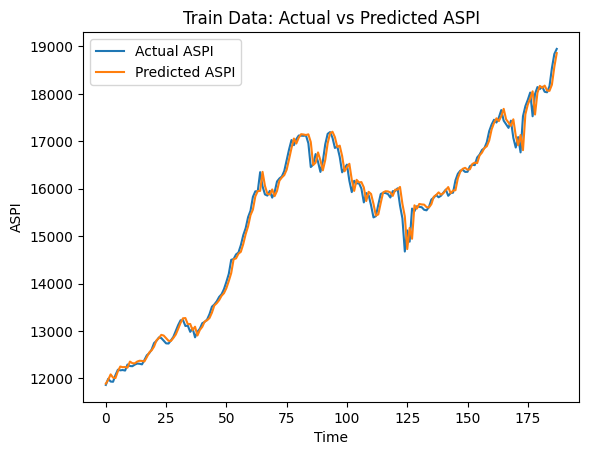

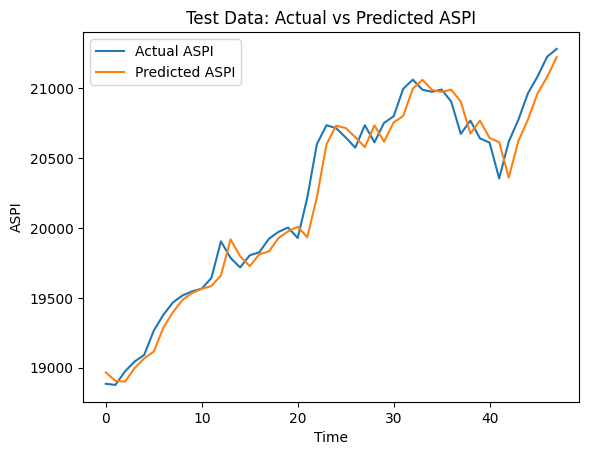

In [ ]:
import matplotlib.pyplot as plt

# ---------- PREDICTIONS ----------
# Train predictions
train_pred = ml_lr.predict(X_train)

# Test predictions
test_pred = ml_lr.predict(X_test)


# ---------- TRAIN PLOT ----------
plt.figure()
plt.plot(y_train.values, label='Actual ASPI')
plt.plot(train_pred, label='Predicted ASPI')
plt.title('Train Data: Actual vs Predicted ASPI')
plt.xlabel('Time')
plt.ylabel('ASPI')
plt.legend()
plt.show()



# ---------- TEST PLOT ----------
plt.figure()
plt.plot(y_test.values, label='Actual ASPI')
plt.plot(test_pred, label='Predicted ASPI')
plt.title('Test Data: Actual vs Predicted ASPI')
plt.xlabel('Time')
plt.ylabel('ASPI')
plt.legend()
plt.show()



**Random Forest Regression Model**

In [ ]:
df_rf = df[['ASPI', 'USD_LKR_lag1', 'ASPI_lag1']].dropna()

X = df_rf[['USD_LKR_lag1', 'ASPI_lag1']]
y = df_rf['ASPI']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    nmse = mse / np.var(y_true)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, nmse, r2

print("TRAIN:", metrics(y_train, rf_train_pred))
print("TEST :", metrics(y_test, rf_test_pred))


TRAIN: (27676.66874150763, np.float64(166.3630630323559), 115.70293619208127, 0.007892423227070284, 0.9921075767729297)
TEST : (4319984.474839919, np.float64(2078.457234306234), 1959.0248671323927, 8.958793697121873, -7.95879369712187)


**Check the multicollinearity before Lasso/ Ridge**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

# Regressors
X_vif = df[['USD_LKR_lag1', 'ASPI_lag1']].dropna()

# Add constant
X_vif = sm.add_constant(X_vif)

# Compute VIF
vif_df = pd.DataFrame()
vif_df['Variable'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]

print(vif_df)

       Variable           VIF
0         const  12388.104573
1  USD_LKR_lag1      2.141205
2     ASPI_lag1      2.141205


**RIDGE & LASSO Regression Model**

In [ ]:
df_model = df[['ASPI', 'USD_LKR_lag1', 'ASPI_lag1']].dropna()

from sklearn.model_selection import train_test_split

X = df_model[['USD_LKR_lag1', 'ASPI_lag1']]
y = df_model['ASPI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred  = ridge.predict(X_test_scaled)

# Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred  = lasso.predict(X_test_scaled)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    nmse = mse / np.var(y_true)
    r2 = r2_score(y_true, y_pred)

    # --- MAPE ---
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mse, rmse, mae, nmse, r2, mape

# Calculate performance
ridge_train_metrics = metrics(y_train, ridge_train_pred)
ridge_test_metrics  = metrics(y_test, ridge_test_pred)

lasso_train_metrics = metrics(y_train, lasso_train_pred)
lasso_test_metrics  = metrics(y_test, lasso_test_pred)

# Results table
import pandas as pd

results = pd.DataFrame({
    'Model': ['Ridge Train', 'Ridge Test', 'Lasso Train', 'Lasso Test'],
    'MSE': [
        ridge_train_metrics[0], ridge_test_metrics[0],
        lasso_train_metrics[0], lasso_test_metrics[0]
    ],
    'RMSE': [
        ridge_train_metrics[1], ridge_test_metrics[1],
        lasso_train_metrics[1], lasso_test_metrics[1]
    ],
    'MAE': [
        ridge_train_metrics[2], ridge_test_metrics[2],
        lasso_train_metrics[2], lasso_test_metrics[2]
    ],
    'NMSE': [
        ridge_train_metrics[3], ridge_test_metrics[3],
        lasso_train_metrics[3], lasso_test_metrics[3]
    ],
    'R²': [
        ridge_train_metrics[4], ridge_test_metrics[4],
        lasso_train_metrics[4], lasso_test_metrics[4]
    ],
    'MAPE (%)': [
        ridge_train_metrics[5], ridge_test_metrics[5],
        lasso_train_metrics[5], lasso_test_metrics[5]
    ]
})

print(results)


         Model           MSE        RMSE         MAE      NMSE        R²  \
0  Ridge Train  32546.087064  180.405341  127.880199  0.009281  0.990719   
1   Ridge Test  20237.125868  142.257252  112.676720  0.041968  0.958032   
2  Lasso Train  32417.275607  180.047981  126.796320  0.009244  0.990756   
3   Lasso Test  17707.493257  133.069505  104.444156  0.036722  0.963278   

   MAPE (%)  
0  0.818941  
1  0.553377  
2  0.811028  
3  0.512883  


Lasso has:

Lower RMSE

Lower MAE

Higher R²

Lower MAPE

Small train–test gap

👉 That means better generalization
👉 No overfitting
👉 Very stable model

**Identify the Intercepts and Coefficients of Ridge and Lasso Regression models and Print the Final Model**

In [ ]:
# -------------------------------
# Coefficients + Intercept
# -------------------------------

coef_table = pd.DataFrame({
    'Variable': X.columns,
    'Ridge Coefficient': ridge.coef_,
    'Lasso Coefficient': lasso.coef_
})

print("\n=== Model Coefficients ===")
print(coef_table)

print("\nRidge Intercept (Constant):", ridge.intercept_)
print("Lasso Intercept (Constant):", lasso.intercept_)

# -------------------------------
# Final Estimated Lasso Equation
# -------------------------------

print("\n=== Final Lasso Model Equation ===")
print(f"ASPI_t = {lasso.intercept_:.4f} "
      f"+ ({lasso.coef_[0]:.4f} * USD_LKR_lag1) "
      f"+ ({lasso.coef_[1]:.4f} * ASPI_lag1)")


=== Model Coefficients ===
       Variable  Ridge Coefficient  Lasso Coefficient
0  USD_LKR_lag1          32.288784          24.985516
1     ASPI_lag1        1836.490229        1850.067196

Ridge Intercept (Constant): 15346.641354166664
Lasso Intercept (Constant): 15346.641354166664

=== Final Lasso Model Equation ===
ASPI_t = 15346.6414 + (24.9855 * USD_LKR_lag1) + (1850.0672 * ASPI_lag1)


**Actual vs Predicted – TEST DATA Plot-(Lasso Regression Model)**

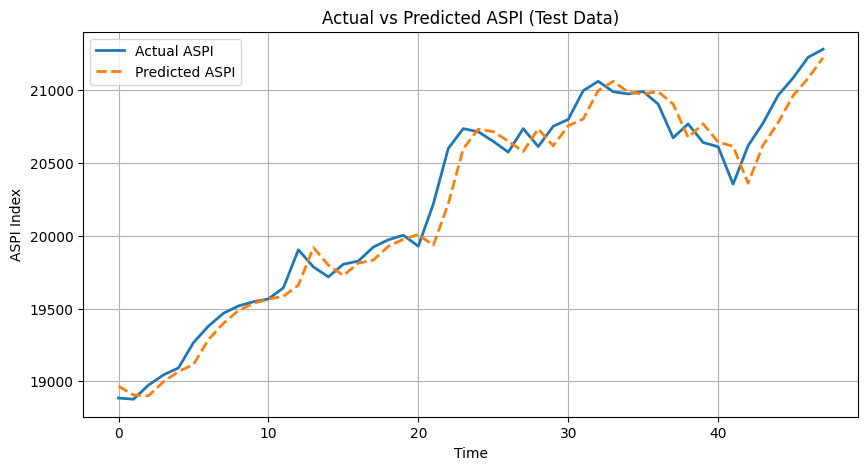

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays (safe side)
y_test_actual = np.array(y_test)
y_test_pred = np.array(y_test_pred)

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual ASPI', linewidth=2)
plt.plot(y_test_pred, label='Predicted ASPI', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted ASPI (Test Data)')
plt.xlabel('Time')
plt.ylabel('ASPI Index')
plt.legend()
plt.grid(True)
plt.show()


**Scatter Plot: Exchange Rate vs ASPI**

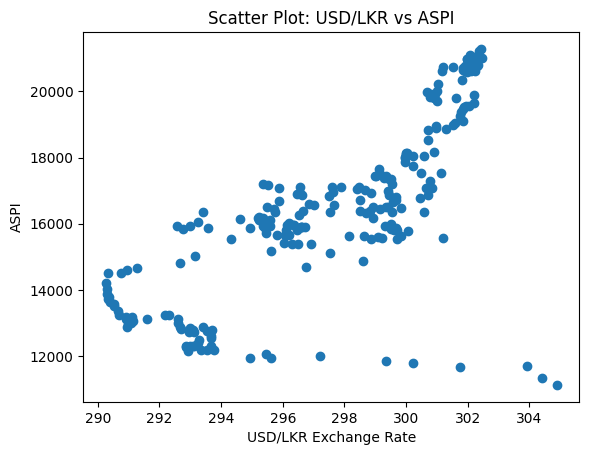

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure()
plt.scatter(df['USD_LKR'], df['ASPI'])

# Labels & title
plt.xlabel('USD/LKR Exchange Rate')
plt.ylabel('ASPI')
plt.title('Scatter Plot: USD/LKR vs ASPI')

# Show plot
plt.show()


**Convert Lasso Coefficients to ORIGINAL SCALE**

In [ ]:
# --- Get scaler parameters ---
means = scaler.mean_
stds  = scaler.scale_

# --- Scaled coefficients ---
beta_scaled = lasso.coef_
intercept_scaled = lasso.intercept_

# --- Convert to original scale ---
beta_original = beta_scaled / stds

intercept_original = intercept_scaled - np.sum((beta_scaled * means) / stds)

# --- Display results ---
coef_original_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient (Original Scale)': beta_original
})

print("\n=== Lasso Coefficients (Original Scale) ===")
print(coef_original_df)

print("\nOriginal Intercept:", intercept_original)



=== Lasso Coefficients (Original Scale) ===
  Variable  Coefficient (Original Scale)
0    const                      7.451676
1  USD_LKR                      0.984636

Original Intercept: -1932.4143030101459
